[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter11_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 11: Continuous-Time Models

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A9); Part B: estimation and inference (B1–B9); Part C: open questions (C1, C3; C2, the critique of an AI answer, is in the slides).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import io
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # reference lines, bands and grid only
LightGray = '#DADADA'
MODEL_COL = {'Data': MainBlue, 'GBM': Orange, 'Merton': Purple, 'Heston': Forest}

HERE = '.'
CHART_DIR = '.'
SEED = 42
DT = 1 / 252


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=4, y=0.0):
    """A single legend for a multi-panel figure, below the figure."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels and not ll.startswith('_'):
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


import tempfile
# with SAVE_TO_DRIVE = True (cell at the top) charts and tables go to OUT_DIR in Drive; otherwise to a temporary folder
HERE = OUT_DIR if globals().get('SAVE_TO_DRIVE') else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it as PNG in OUT_DIR."""
    if globals().get('SAVE_TO_DRIVE'):
        plt.savefig(os.path.join(OUT_DIR, f'{name}.png'), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500 (1990–2026), BET (2000–2026), Bitcoin (2014–2026), VIX (1990–2026).
- 3-month US Treasury bill rate (FRED series DTB3), 1954–2026.
- Equity indices: weekdays only, stale quotes removed (unchanged close and no intraday range), genuine zero returns kept; Bitcoin: 7 days a week; daily log returns, time in years.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, start date)
MARKETS = {
    'sp500':  ('GSPC.INDX',  'S&P 500',                  'index',  '1990-01-01'),
    'bet':    ('BET',        'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC', 'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',    'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Read the daily price file of one symbol (local copy if present, otherwise GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (annual NBR XML archives)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def read_fred(series, start='1954-01-01', end=END):
    """Daily FRED series (Federal Reserve Bank of St. Louis), in original units."""
    key = ('fred', series, start, end)
    if key in _CACHE:
        return _CACHE[key]
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}'
    for attempt in range(4):
        try:
            raw = urllib.request.urlopen(url, timeout=120).read().decode()
            break
        except OSError:
            if attempt == 3:
                raise
    df = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True, na_values='.')
    s = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().loc[start:end].rename(series)
    _CACHE[key] = s
    return s


def load_close(name, start=None, end=END):
    """Daily price, cleaned with the chapter conventions."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    d = read_market(symbol).loc[start:end]
    d = d[d['close'] > 0].dropna(subset=['close'])
    if kind != 'crypto':
        d = d[d.index.dayofweek < 5]          # no weekend quotes
    s = d['close']
    if kind == 'index':
        # stale quote: unchanged close and no intraday range (or high/low unavailable)
        no_range = (d['high'] <= d['low']) if {'high', 'low'} <= set(d.columns) else pd.Series(True, index=d.index)
        s = s[~((s.diff() == 0) & no_range)]
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Actual frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def load_vix(start='1990-01-01', end=END):
    """The VIX index (CBOE), daily close, in annualised volatility points (%)."""
    s = read_market('VIX.INDX')['close'].loc[start:end]
    s = s[(s > 0) & (s.index.dayofweek < 5)].dropna()
    return s.rename('vix')


# daily log returns (not in %), each series on its own calendar
rets = {k: log_returns(k) for k in ['sp500', 'bet', 'btc']}
DTS = {'sp500': 1 / 252, 'bet': 1 / 252, 'btc': 1 / 365}
for k, r in rets.items():
    print(f'{LABELS[k]:26s}', r.index[0].date(), '->', r.index[-1].date(), len(r), 'obs')

## Continuous-time models

- Brownian motion, quadratic variation, Itô and Stratonovich sums; Euler–Maruyama and Milstein.
- Geometric Brownian motion (GBM), Ornstein–Uhlenbeck (OU), Merton jump-diffusion, Lee–Mykland jump test, Heston stochastic volatility.
- Stylised facts: excess kurtosis, the Hill statistic of the largest losses, autocorrelation of $|r_t|$.

In [ ]:
# =============================================================================
# BROWNIAN MOTION
# =============================================================================
def scaled_random_walk(n, n_paths, rng):
    """Scaled random walk W_n(t) = S_[nt] / sqrt(n), with equally likely +1/-1 steps, on the grid t = k/n."""
    steps = rng.choice([-1.0, 1.0], size=(n_paths, n))
    S = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(steps, axis=1)], axis=1)
    return np.linspace(0, 1, n + 1), S / np.sqrt(n)


def bm_paths(n_paths, n_steps, T, rng):
    """Standard Brownian motion paths on [0, T]: W_0 = 0, independent N(0, dt) increments."""
    dt = T / n_steps
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)
    return np.linspace(0, T, n_steps + 1), W


def quadratic_variation(W):
    """Sum of squared increments (quadratic variation on the given grid)."""
    return np.sum(np.diff(W, axis=-1) ** 2, axis=-1)


def total_variation(W):
    """Sum of absolute increments (total variation on the given grid)."""
    return np.sum(np.abs(np.diff(W, axis=-1)), axis=-1)


def ito_stratonovich(W):
    """Ito (left endpoint) and Stratonovich (midpoint) sums for the integral of W with respect to W."""
    dW = np.diff(W, axis=-1)
    ito = np.sum(W[..., :-1] * dW, axis=-1)
    strat = np.sum(0.5 * (W[..., :-1] + W[..., 1:]) * dW, axis=-1)
    return ito, strat


def max_prob(W, level=1.0):
    """Share of paths whose maximum on [0, T] exceeds the given level."""
    return float(np.mean(W.max(axis=1) > level))


# =============================================================================
# DISCRETISATION SCHEMES (Higham's test equation: dX = lam X dt + mu X dW)
# =============================================================================
def em_milstein_gbm(x0, lam, mu, dW, dt):
    """Euler-Maruyama and Milstein for dX = lam X dt + mu X dW, with Brownian increments dW (n_paths x n)."""
    xe = np.full(dW.shape[0], x0, dtype=float)
    xm = xe.copy()
    for k in range(dW.shape[1]):
        d = dW[:, k]
        xe = xe + lam * xe * dt + mu * xe * d
        xm = xm + lam * xm * dt + mu * xm * d + 0.5 * mu ** 2 * xm * (d ** 2 - dt)
    return xe, xm


def convergence_study(rng, x0=1.0, lam=2.0, mu=1.0, T=1.0, n_fine=2 ** 11, n_paths=20000,
                      ratios=(1, 2, 4, 8, 16, 32, 64), return_paths=False):
    """Strong error E|X_T - X^h_T| and weak error |E X^h_T - E X_T| for steps dt = ratio * T / n_fine.
    With return_paths=True it also returns the path x step matrices (absolute EM and Milstein errors, EM X^h_T),
    used for the whole-path bootstrap (the same paths at every step size)."""
    dt_f = T / n_fine
    dW = rng.standard_normal((n_paths, n_fine)) * np.sqrt(dt_f)
    WT = dW.sum(axis=1)
    x_true = x0 * np.exp((lam - 0.5 * mu ** 2) * T + mu * WT)
    ex = x0 * np.exp(lam * T)                       # E X_T exact
    rows, ae, am, xs = [], [], [], []
    for r in ratios:
        dWr = dW.reshape(n_paths, n_fine // r, r).sum(axis=2)
        h = r * dt_f
        xe, xm = em_milstein_gbm(x0, lam, mu, dWr, h)
        ae.append(np.abs(x_true - xe))
        am.append(np.abs(x_true - xm))
        xs.append(xe)
        rows.append(dict(dt=h, strong_em=np.mean(np.abs(x_true - xe)), strong_mil=np.mean(np.abs(x_true - xm)),
                         strong_em_se=np.std(np.abs(x_true - xe)) / np.sqrt(n_paths),
                         strong_mil_se=np.std(np.abs(x_true - xm)) / np.sqrt(n_paths),
                         weak_em_exact=abs(x0 * (1 + lam * h) ** round(T / h) - ex),
                         weak_em_mc=abs(xe.mean() - ex), weak_mil_mc=abs(xm.mean() - ex)))
    d = pd.DataFrame(rows)
    if return_paths:
        return d, dict(abs_em=np.column_stack(ae), abs_mil=np.column_stack(am), x_em=np.column_stack(xs), ex=ex)
    return d


def slope_boot(dt, M, rng, n_boot=1000, level=0.95, target=None):
    """Log-log slope with a whole-path bootstrap interval: the rows of M (path x step) are resampled,
    keeping all resolutions together; the error at each step is the column mean
    (target=None, strong error) or |column mean - target| (Monte Carlo weak error)."""
    x = np.log(np.asarray(dt))
    f = (lambda A: A.mean(axis=0)) if target is None else (lambda A: np.abs(A.mean(axis=0) - target))
    slope = np.polyfit(x, np.log(f(M)), 1)[0]
    n = M.shape[0]
    b = np.empty(n_boot)
    for i in range(n_boot):
        b[i] = np.polyfit(x, np.log(np.maximum(f(M[rng.integers(0, n, n)]), 1e-300)), 1)[0]
    q = np.quantile(b, [(1 - level) / 2, (1 + level) / 2])
    return dict(slope=float(slope), se=float(b.std()), lo=float(q[0]), hi=float(q[1]))


def slope_ci(dt, err, level=0.95):
    """Slope of the regression of log(error) on log(dt), with standard error and t confidence interval."""
    x, y = np.log(np.asarray(dt)), np.log(np.asarray(err))
    res = stats.linregress(x, y)
    q = stats.t.ppf(0.5 + level / 2, len(x) - 2)
    return dict(slope=res.slope, se=res.stderr, lo=res.slope - q * res.stderr, hi=res.slope + q * res.stderr,
                intercept=res.intercept)


# =============================================================================
# GEOMETRIC BROWNIAN MOTION (GBM)
# =============================================================================
def gbm_paths(S0, mu, sigma, T, n_steps, n_paths, rng):
    """Exact solution S_t = S_0 exp((mu - sigma^2/2) t + sigma W_t) on a regular grid."""
    t, W = bm_paths(n_paths, n_steps, T, rng)
    return t, S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * W)


def gbm_mle(r, dt):
    """Maximum likelihood for GBM from log returns r (same frequency dt, in years).

    r_t ~ N((mu - sigma^2/2) dt, sigma^2 dt), i.i.d.  =>  sigma^2 = var(r)/dt,  mu = mean(r)/dt + sigma^2/2.
    Standard errors: se(sigma) = sigma / sqrt(2n); se(log drift) = sigma / sqrt(n dt) (depends only on the span)."""
    r = np.asarray(r)
    n = len(r)
    s2 = r.var() / dt
    sigma = np.sqrt(s2)
    m = r.mean() / dt                       # log drift (mu - sigma^2/2)
    return dict(n=n, years=n * dt, sigma=sigma, se_sigma=sigma / np.sqrt(2 * n), m=m, se_m=sigma / np.sqrt(n * dt),
                mu=m + 0.5 * s2)


def gbm_simulate_returns(m, sigma, n, dt, rng):
    """I.i.d. Normal log returns of a GBM (log drift m, volatility sigma)."""
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n)


# =============================================================================
# ORNSTEIN-UHLENBECK / VASICEK
# =============================================================================
def ou_exact_path(x0, kappa, theta, sigma, dt, n, rng, z=None):
    """Exact discretisation: x_{t+dt} = theta + (x_t - theta) e^{-kappa dt} + eps, eps ~ N(0, sigma^2 (1 - e^{-2 kappa dt}) / (2 kappa))."""
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    z = rng.standard_normal(n) if z is None else z
    x = np.empty(n + 1)
    x[0] = x0
    for k in range(n):
        x[k + 1] = theta + (x[k] - theta) * b + sd * z[k]
    return x


def ou_mle(x, dt):
    """Maximum likelihood estimator (conditional on x_0) of the OU process: the exact AR(1) regression.

    x_{t+1} = a + b x_t + e;  kappa = -ln b / dt;  theta = a / (1 - b);  sigma = s_e sqrt(2 kappa / (1 - b^2)).
    Standard errors of kappa, theta and the half-life: delta method from the OLS covariance of (a, b)."""
    x = np.asarray(x, dtype=float)
    y, z = x[1:], x[:-1]
    X = np.column_stack([np.ones_like(z), z])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b = coef
    e = y - X @ coef
    n = len(y)
    s2 = e @ e / n
    cov = s2 * np.linalg.inv(X.T @ X)
    kappa = -np.log(b) / dt
    theta = a / (1 - b)
    sigma = np.sqrt(s2 * 2 * kappa / (1 - b ** 2))
    g_k = np.array([0.0, -1 / (b * dt)])                       # d kappa / d(a, b)
    g_t = np.array([1 / (1 - b), a / (1 - b) ** 2])           # d theta / d(a, b)
    se_k = float(np.sqrt(g_k @ cov @ g_k))
    se_t = float(np.sqrt(g_t @ cov @ g_t))
    hl = np.log(2) / kappa
    return dict(n=n, a=a, b=b, kappa=kappa, se_kappa=se_k, theta=theta, se_theta=se_t, sigma=sigma,
                half_life=hl, se_half_life=hl / kappa * se_k, stat_sd=sigma / np.sqrt(2 * kappa))


def ou_bias_mc(kappa, theta, sigma, dt, n, n_sim, rng):
    """Sampling distribution of the estimated kappa: n_sim exact OU paths (started from the stationary distribution)."""
    from scipy.signal import lfilter
    b = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - b ** 2) / (2 * kappa))
    out = np.empty(n_sim)
    for i in range(n_sim):
        e = sd * rng.standard_normal(n)
        e[0] = sigma / np.sqrt(2 * kappa) * rng.standard_normal()
        x = theta + lfilter([1.0], [1.0, -b], e)
        out[i] = ou_mle(x, dt)['kappa']
    return out


# =============================================================================
# NONLINEAR DIFFUSIONS: EXACT (CIR) VS EULER LIKELIHOOD; CKLS; NONPARAMETRIC ESTIMATION
# =============================================================================
def vasicek_loglik(x, dt, kappa, theta, sigma, per_obs=False):
    """Exact Vasicek log-likelihood (Normal transition, exact AR(1))."""
    r0, r1 = x[:-1], x[1:]
    b = np.exp(-kappa * dt)
    ll = stats.norm.logpdf(r1, theta + (r0 - theta) * b, sigma * np.sqrt((1 - b * b) / (2 * kappa)))
    return ll if per_obs else ll.sum()


def cir_loglik(x, dt, kappa, theta, sigma, per_obs=False):
    """Exact CIR log-likelihood: 2c r_{t+dt} | r_t ~ noncentral chi-square with 4 kappa theta / sigma^2 degrees of freedom
    and noncentrality 2c r_t e^{-kappa dt}, c = 2 kappa / (sigma^2 (1 - e^{-kappa dt})) (Cox, Ingersoll, Ross 1985)."""
    r0, r1 = x[:-1], x[1:]
    c = 2 * kappa / (sigma ** 2 * (1 - np.exp(-kappa * dt)))
    ll = np.log(2 * c) + stats.ncx2.logpdf(2 * c * r1, 4 * kappa * theta / sigma ** 2, 2 * c * r0 * np.exp(-kappa * dt))
    return ll if per_obs else ll.sum()


def euler_loglik(x, dt, kappa, theta, sigma, gamma, per_obs=False):
    """Euler (Gaussian) pseudo-likelihood for dr = kappa (theta - r) dt + sigma r^gamma dW
    (gamma = 0: Vasicek, gamma = 1/2: CIR, free gamma: Chan, Karolyi, Longstaff, Sanders 1992)."""
    r0, r1 = x[:-1], x[1:]
    ll = stats.norm.logpdf(r1, r0 + kappa * (theta - r0) * dt, sigma * r0 ** gamma * np.sqrt(dt))
    return ll if per_obs else ll.sum()


def _fit(nll, p0):
    best = None
    for scale in (1.0, 0.5, 2.0):
        q0 = np.array(p0, dtype=float)
        q0[0] *= scale
        res = optimize.minimize(nll, q0, method='Nelder-Mead', options=dict(maxiter=40000, maxfev=40000, xatol=1e-10, fatol=1e-8))
        res = optimize.minimize(nll, res.x, method='Nelder-Mead', options=dict(maxiter=40000, maxfev=40000, xatol=1e-10, fatol=1e-8))
        if best is None or res.fun < best.fun:
            best = res
    return best


def short_rate_fits(x, dt):
    """Vasicek (exact and Euler), CIR (exact and Euler) and CKLS (Euler) on the same series; Hessian standard errors
    (for CKLS also robust sandwich errors, since the Gaussian Euler likelihood is only a quasi-likelihood)."""
    x = np.asarray(x, dtype=float)
    specs = {
        'vasicek_exact': (lambda p: vasicek_loglik(x, dt, p[0], p[1], p[2]), lambda q: (q[0], q[1], np.exp(q[2])), 0.0),
        'vasicek_euler': (lambda p: euler_loglik(x, dt, p[0], p[1], p[2], 0.0), lambda q: (q[0], q[1], np.exp(q[2])), 0.0),
        'cir_euler': (lambda p: euler_loglik(x, dt, p[0], p[1], p[2], 0.5), lambda q: (q[0], q[1], np.exp(q[2])), 0.5),
        'cir_exact': (lambda p: cir_loglik(x, dt, p[0], p[1], p[2]), lambda q: (q[0], q[1], np.exp(q[2])), 0.5),
    }
    out = {}
    m = x.mean()
    for name, (ll, unpack, g) in specs.items():
        s0 = 0.015 if g == 0 else 0.015 / np.sqrt(m)

        def nll(q, ll=ll, unpack=unpack):
            k, th, sg = unpack(q)
            if k <= 0 or th <= 0:
                return 1e18
            v = -ll((k, th, sg))
            return v if np.isfinite(v) else 1e18
        res = _fit(nll, [0.2, m, np.log(s0)])
        th = np.array(unpack(res.x))
        H = numerical_hessian(lambda t, ll=ll: -ll(t), th)
        se = np.sqrt(np.maximum(np.diag(np.linalg.inv(H)), 0))
        out[name] = dict(kappa=th[0], theta=th[1], sigma=th[2], gamma=g, se_kappa=se[0], se_theta=se[1], se_sigma=se[2],
                         loglik=-res.fun)
    # CKLS: free gamma
    best = None
    for g0 in (0.5, 1.0, 1.5):
        def nll(q):
            if q[0] <= 0 or q[1] <= 0:
                return 1e18
            v = -euler_loglik(x, dt, q[0], q[1], np.exp(q[2]), q[3])
            return v if np.isfinite(v) else 1e18
        res = _fit(nll, [0.2, m, np.log(0.015 * m ** (-g0)), g0])
        if best is None or res.fun < best.fun:
            best = res
    th = np.array([best.x[0], best.x[1], np.exp(best.x[2]), best.x[3]])
    f = lambda t: euler_loglik(x, dt, *t)
    H = -numerical_hessian(f, th)
    Hi = np.linalg.inv(H)
    h = 1e-5 * np.maximum(np.abs(th), 1e-2)
    sc = np.column_stack([(euler_loglik(x, dt, *(th + e), per_obs=True) - euler_loglik(x, dt, *(th - e), per_obs=True)) / (2 * hi)
                          for e, hi in zip(np.diag(h), h)])
    V = Hi @ (sc.T @ sc) @ Hi
    Vh = Hi @ hac_cov(sc) @ Hi
    out['ckls'] = dict(kappa=th[0], theta=th[1], sigma=th[2], gamma=th[3], se_gamma=float(np.sqrt(Hi[3, 3])),
                       se_gamma_rob=float(np.sqrt(V[3, 3])), se_gamma_hac=float(np.sqrt(Vh[3, 3])),
                       hac_lags=nw_lags(len(sc)), se_kappa=float(np.sqrt(Hi[0, 0])), loglik=-best.fun)
    c = out['ckls']
    c['lr_g0'] = 2 * (c['loglik'] - out['vasicek_euler']['loglik'])
    c['lr_g05'] = 2 * (c['loglik'] - out['cir_euler']['loglik'])
    c['wald_g0'] = (c['gamma'] / c['se_gamma_rob']) ** 2
    c['wald_g05'] = ((c['gamma'] - 0.5) / c['se_gamma_rob']) ** 2
    c['wald_g0_hac'] = (c['gamma'] / c['se_gamma_hac']) ** 2
    c['wald_g05_hac'] = ((c['gamma'] - 0.5) / c['se_gamma_hac']) ** 2
    L0 = nw_lags(len(sc))                   # sensitivity: five times as many lags
    se5 = float(np.sqrt((Hi @ hac_cov(sc, 5 * L0) @ Hi)[3, 3]))
    c.update(hac_lags5=5 * L0, se_gamma_hac5=se5, wald_g0_hac5=(c['gamma'] / se5) ** 2,
             wald_g05_hac5=((c['gamma'] - 0.5) / se5) ** 2)
    out['n'] = len(x) - 1
    return out


def nw_lags(n):
    """Newey-West number of lags: floor(4 (n / 100)^(2/9))."""
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def hac_cov(sc, L=None):
    """Long-run covariance of the scores (Newey and West, 1987): Bartlett kernel with L lags; accounts for
    autocorrelation of the scores (for example, from persistent volatility omitted from the model)."""
    sc = np.asarray(sc) - np.asarray(sc).mean(axis=0)
    L = nw_lags(len(sc)) if L is None else L
    S = sc.T @ sc
    for j in range(1, L + 1):
        G = sc[j:].T @ sc[:-j]
        S += (1 - j / (L + 1)) * (G + G.T)
    return S


def nw_drift_diffusion(x, dt, grid, h=None):
    """Nadaraya-Watson estimators (Gaussian kernel) of the drift a(r) = E[dr | r] / dt and the diffusion
    b^2(r) = E[(dr)^2 | r] / dt (Stanton 1997; Bandi and Phillips 2003); pointwise heteroskedasticity-robust standard errors
    (serial dependence of the errors is ignored)."""
    x = np.asarray(x, dtype=float)
    r0, d = x[:-1], np.diff(x)
    if h is None:
        h = 1.06 * r0.std() * len(r0) ** (-0.2)
    out = {'grid': np.asarray(grid), 'h': h}
    for name, y in [('drift', d / dt), ('diff2', d ** 2 / dt)]:
        m, se = [], []
        for g in grid:
            w = np.exp(-0.5 * ((r0 - g) / h) ** 2)
            w /= w.sum()
            mm = w @ y
            m.append(mm)
            se.append(np.sqrt((w ** 2) @ (y - mm) ** 2))
        out[name], out[name + '_se'] = np.array(m), np.array(se)
    return out


# =============================================================================
# MERTON: JUMP-DIFFUSION
# =============================================================================
def merton_logpdf(r, dt, m, sigma, lam, mu_j, s_j, kmax=12):
    """Log-density of log returns over a step dt:  r = m dt + sigma W_dt + the sum of N jumps N(mu_j, s_j^2),
    N ~ Poisson(lam dt). The density is a mixture of Normal distributions weighted by the Poisson probabilities."""
    r = np.asarray(r)[:, None]
    k = np.arange(kmax + 1)[None, :]
    w = stats.poisson.pmf(k, lam * dt)
    mean = m * dt + k * mu_j
    var = sigma ** 2 * dt + k * s_j ** 2
    dens = (w * np.exp(-0.5 * (r - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)).sum(axis=1)
    return np.log(np.maximum(dens, 1e-300))


def _merton_unpack(p, sigma_min=0.0):
    return p[0], sigma_min + np.exp(p[1]), np.exp(p[2]), p[3], np.exp(p[4])


def merton_mle(r, dt, starts=None, sigma_min=0.0):
    """Maximum likelihood for Merton (m, sigma, lam, mu_j, s_j); several starting points.
    sigma_min > 0 restricts the parameter space to sigma >= sigma_min (sigma = sigma_min + e^q): the unrestricted
    likelihood is unbounded (sigma -> 0 with m dt equal to an observed return), the restricted one is bounded.
    Standard errors: inverse of the numerical Hessian in the original parameters (delta method)."""
    r = np.asarray(r)
    sd = r.std()
    unpack = lambda p: _merton_unpack(p, sigma_min)
    nll = lambda p: -merton_logpdf(r, dt, *unpack(p)).sum()
    if starts is None:
        starts = []
        s0 = np.log(max(0.7 * sd / np.sqrt(dt) - sigma_min, 1e-3))
        for lam0 in (2.0, 10.0, 40.0):
            for sj0 in (1.5, 3.0):
                starts.append([r.mean() / dt, s0, np.log(lam0), -0.5 * sd, np.log(sj0 * sd)])
    best = None
    for s0 in starts:
        res = optimize.minimize(nll, s0, method='Nelder-Mead', options=dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-7))
        res = optimize.minimize(nll, res.x, method='BFGS')
        if best is None or res.fun < best.fun:
            best = res
    m, sigma, lam, mu_j, s_j = unpack(best.x)
    theta = np.array([m, sigma, lam, mu_j, s_j])
    nll_orig = lambda th: -merton_logpdf(r, dt, *th).sum()
    H = numerical_hessian(nll_orig, theta)
    try:
        cov = np.linalg.inv(H)
        se = np.sqrt(np.maximum(np.diag(cov), 0))
    except np.linalg.LinAlgError:
        se = np.full(5, np.nan)
    return dict(m=m, sigma=sigma, lam=lam, mu_j=mu_j, s_j=s_j, se=dict(zip(['m', 'sigma', 'lam', 'mu_j', 's_j'], se)),
                loglik=-best.fun, n=len(r))


def numerical_hessian(f, x, rel=1e-4):
    """Hessian by central finite differences."""
    x = np.asarray(x, dtype=float)
    k = len(x)
    h = rel * np.maximum(np.abs(x), 1e-3)
    H = np.empty((k, k))
    for i in range(k):
        for j in range(i, k):
            ei, ej = np.zeros(k), np.zeros(k)
            ei[i], ej[j] = h[i], h[j]
            H[i, j] = H[j, i] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h[i] * h[j])
    return H


def merton_moments(dt, sigma, lam, mu_j, s_j, m=0.0):
    """Mean, variance, skewness and excess kurtosis of the Merton return over a step dt (cumulants)."""
    k1 = m * dt + lam * dt * mu_j
    k2 = sigma ** 2 * dt + lam * dt * (mu_j ** 2 + s_j ** 2)
    k3 = lam * dt * (mu_j ** 3 + 3 * mu_j * s_j ** 2)
    k4 = lam * dt * (mu_j ** 4 + 6 * mu_j ** 2 * s_j ** 2 + 3 * s_j ** 4)
    return dict(mean=k1, var=k2, skew=k3 / k2 ** 1.5, exkurt=k4 / k2 ** 2)


def merton_simulate_returns(m, sigma, lam, mu_j, s_j, n, dt, rng):
    """Log returns simulated from the Merton model."""
    N = rng.poisson(lam * dt, n)
    jumps = mu_j * N + s_j * np.sqrt(N) * rng.standard_normal(n)
    return m * dt + sigma * np.sqrt(dt) * rng.standard_normal(n) + jumps


def _lr_stat(r, dt, sigma_min):
    """LR statistic, GBM vs Merton, on the restricted space sigma >= sigma_min, with the same optimisation rule
    (the six default starting points of merton_mle) for every sample."""
    l0 = stats.norm.logpdf(r, r.mean(), r.std()).sum()
    mf = merton_mle(r, dt, sigma_min=sigma_min)
    return max(2 * (mf['loglik'] - l0), 0.0), mf


def _lr_boot_one(args):
    rb, dt, sigma_min = args
    return _lr_stat(rb, dt, sigma_min)[0]


def lr_bootstrap(r, dt, n_boot, rng, sigma_min=0.05, n_jobs=1):
    """Likelihood-ratio test of GBM (no jumps) against Merton, with a parametric-bootstrap p-value.
    Under the null, lam = 0 lies on the boundary and mu_j, s_j are unidentified: the chi-square distribution does not apply.
    The unrestricted Merton likelihood is unbounded, so the statistic is defined on the restricted space
    sigma >= sigma_min; the same restriction and the same starting points for the observed sample and for every
    bootstrap sample. p-value: (1 + number of exceedances) / (1 + n_boot), with a 95% binomial upper bound."""
    r = np.asarray(r)
    g = gbm_mle(r, dt)
    lr, mf = _lr_stat(r, dt, sigma_min)
    samples = [gbm_simulate_returns(g['m'], g['sigma'], len(r), dt, rng) for _ in range(n_boot)]
    jobs = [(rb, dt, sigma_min) for rb in samples]
    if n_jobs > 1:
        import multiprocessing as mp
        with mp.get_context('fork').Pool(n_jobs) as pool:
            boot = np.array(pool.map(_lr_boot_one, jobs))
    else:
        boot = np.array([_lr_boot_one(j) for j in jobs])
    k = int(np.sum(boot >= lr))
    return dict(lr=lr, n_exceed=k, p_boot=(k + 1) / (n_boot + 1), p_upper95=float(stats.beta.ppf(0.95, k + 1, n_boot - k)),
                boot=boot, crit95=float(np.quantile(boot, 0.95)), merton=mf, sigma_min=sigma_min)


# =============================================================================
# THE LEE-MYKLAND JUMP TEST
# =============================================================================
def lee_mykland(r, K=16, alpha=0.01):
    """Statistic L_t = r_t / sigma_t, with sigma_t^2 = bipower variation over the previous K-1 returns;
    a jump is detected if (|L_t| - C_n) / S_n exceeds the 1 - alpha quantile of the Gumbel distribution (Lee & Mykland, 2008)."""
    r = pd.Series(r).dropna()
    a = r.abs()
    bpv = (a * a.shift(1)).rolling(K - 2).sum().shift(1) / (K - 2)
    L = (r / np.sqrt(bpv)).dropna()
    n = len(L)
    c = np.sqrt(2 / np.pi)
    ln = np.log(n)
    Cn = np.sqrt(2 * ln) / c - (np.log(np.pi) + np.log(ln)) / (2 * c * np.sqrt(2 * ln))
    Sn = 1 / (c * np.sqrt(2 * ln))
    crit = -np.log(-np.log(1 - alpha))
    stat = (L.abs() - Cn) / Sn
    return pd.DataFrame({'r': r.reindex(L.index), 'L': L, 'stat': stat, 'jump': stat > crit}), crit


# =============================================================================
# HESTON: STOCHASTIC VOLATILITY
# =============================================================================
def heston_paths(S0, v0, mu, kappa, theta, xi, rho, T, n_steps, n_paths, rng, antithetic=False):
    """Full-truncation Euler scheme (Lord et al., 2010) for log S and v.
    d ln S = (mu - v/2) dt + sqrt(v) dW1;  dv = kappa (theta - v) dt + xi sqrt(v) dW2;  corr(dW1, dW2) = rho."""
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    x = np.full(n_paths, np.log(S0))
    v = np.full(n_paths, v0, dtype=float)
    X = np.empty((n_steps + 1, n_paths))
    V = np.empty((n_steps + 1, n_paths))
    X[0], V[0] = x, v
    for k in range(n_steps):
        z1 = rng.standard_normal(m)
        z2 = rng.standard_normal(m)
        if antithetic:
            z1, z2 = np.concatenate([z1, -z1]), np.concatenate([z2, -z2])
        w2 = rho * z1 + np.sqrt(1 - rho ** 2) * z2
        vp = np.maximum(v, 0.0)
        x = x + (mu - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * w2
        X[k + 1], V[k + 1] = x, np.maximum(v, 0.0)
    return np.linspace(0, T, n_steps + 1), np.exp(X), V


def heston_from_vix(vix, price, dt):
    """Heston parameters from the VIX: v_t = (VIX_t / 100)^2 as a variance proxy; the discretised CIR regression
    (v_{t+1} - v_t) / sqrt(v_t) = kappa theta dt / sqrt(v_t) - kappa dt sqrt(v_t) + xi sqrt(dt) eps;
    rho = correlation between return shocks and variance shocks.
    Price and VIX are first aligned on common days; returns are then computed on this common grid,
    so that the return and the change in v cover the same interval."""
    d = pd.concat([vix.rename('vix'), price.rename('p')], axis=1, join='inner').dropna()
    d['r'] = np.log(d['p']).diff()
    d = d.dropna()
    v = (d['vix'] / 100) ** 2
    y = (v.shift(-1) - v) / np.sqrt(v)
    X = np.column_stack([dt / np.sqrt(v), -dt * np.sqrt(v)])
    ok = y.notna().values
    beta, *_ = np.linalg.lstsq(X[ok], y.values[ok], rcond=None)
    kappa = beta[1]
    theta = beta[0] / kappa
    res = y.values[ok] - X[ok] @ beta
    xi = res.std() / np.sqrt(dt)
    dv = (v.shift(-1) - v - kappa * (theta - v) * dt) / np.sqrt(v)
    zr = (d['r'].shift(-1) - d['r'].mean()) / np.sqrt(v)
    rho = pd.concat([dv, zr], axis=1).dropna().corr().iloc[0, 1]
    return dict(kappa=kappa, theta=theta, xi=xi, rho=rho, v0=float(v.iloc[-1]), n=int(ok.sum()),
                feller=2 * kappa * theta / xi ** 2, mean_vix=float(d['vix'].mean()),
                real_var=float(d['r'].var() / dt))


def heston_from_proxy(logret, dt, window=21):
    """The same CIR regression, with the variance proxied by annualised realised variance over a rolling window
    (for markets without a volatility index, e.g. BET and Bitcoin)."""
    rv = (logret ** 2).rolling(window).mean() / dt          # RV_t = (1/21) sum_{j=0}^{20} r_{t-j}^2 / dt
    proxy = 100 * np.sqrt(rv)
    price = np.exp(logret.cumsum())                           # price rebuilt on the returns calendar
    return heston_from_vix(proxy.dropna(), price, dt)


def heston_simulate_returns(p, n, dt, rng, mu=0.0, burn=500):
    """Daily log returns simulated from Heston (with a burn-in of burn steps)."""
    T = (n + burn) * dt
    _, S, _ = heston_paths(1.0, p['theta'], mu, p['kappa'], p['theta'], p['xi'], p['rho'], T, n + burn, 1, rng)
    return np.diff(np.log(S[:, 0]))[burn:]


def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes price of a European call option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d1 - sigma * np.sqrt(T))


def implied_vol(price, S, K, T, r=0.0):
    """Black-Scholes implied volatility (root by Brent's method)."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if price <= intrinsic + 1e-10:
        return np.nan
    return optimize.brentq(lambda s: bs_call(S, K, T, s, r) - price, 1e-4, 5.0)


def heston_smile(p, T, strikes, rng, n_paths=100000, n_steps=126):
    """Monte Carlo call prices under Heston (zero rate, mu = 0) and their implied volatilities."""
    _, S, _ = heston_paths(1.0, p['v0'], 0.0, p['kappa'], p['theta'], p['xi'], p['rho'], T, n_steps, n_paths, rng,
                           antithetic=True)
    ST = S[-1] / S[-1].mean()                 # martingale correction: E[S_T] = S_0 = 1
    return np.array([implied_vol(np.maximum(ST - K, 0).mean(), 1.0, K, T) for K in strikes])


# =============================================================================
# STYLISED FACTS
# =============================================================================
def acf(x, lags):
    x = np.asarray(x) - np.mean(x)
    d = x @ x
    return np.array([x[k:] @ x[:-k] / d for k in lags])


def hill(x, share=0.05):
    """Hill statistic for the largest k = share * n values of x (n = total number of observations);
    with x = -r: the largest losses, k = 5% of all returns. It estimates the tail index only under
    regular variation (a Pareto-type tail); for a Normal tail it is a descriptive statistic of the tail shape."""
    x = np.sort(np.asarray(x))[::-1]
    k = int(share * len(x))
    return 1 / np.mean(np.log(x[:k] / x[k]))


def stylised(r, lags=range(1, 51)):
    """Stylised facts used to compare the models with the data."""
    r = np.asarray(r)
    a = acf(np.abs(r), list(lags))
    return dict(exkurt=float(stats.kurtosis(r)), skew=float(stats.skew(r)), hill=float(hill(-r)),
                acf_abs1=float(a[0]), acf_abs_sum20=float(a[:20].sum()), acf_r1=float(acf(r, [1])[0]),
                acf_abs=a)

## Seminar functions

- Simulation of the stylised facts of a fitted model (used in Part C).

In [ ]:
def simulate_stats(model, p, n, dt, n_sim, rng, mu=0.0):
    out = []
    for _ in range(n_sim):
        if model == 'GBM':
            x = gbm_simulate_returns(p['m'], p['sigma'], n, dt, rng)
        elif model == 'Merton':
            x = merton_simulate_returns(p['m'], p['sigma'], p['lam'], p['mu_j'], p['s_j'], n, dt, rng)
        else:
            x = heston_simulate_returns(p, n, dt, rng, mu=mu)
        out.append(stylised(x))
    return out

## Part A — derivations

### A1. GBM under P and Q (Girsanov) [Solved]

- $\mu = 8\%$, $\sigma = 20\%$, $r = 3\%$: market price of risk, $\mathbb{E}^Q[S_T]$, probability of a loss under $P$ and under $Q$.

In [7]:
# Solution
def a1_girsanov(mu=0.08, sigma=0.20, r=0.03, T=10.0):
    """A1: GBM under P and under Q: the market price of risk theta = (mu - r) / sigma, the Radon-Nikodym density,
    the probability of a loss after T years under the two measures."""
    th = (mu - r) / sigma
    mP, mQ = mu - 0.5 * sigma ** 2, r - 0.5 * sigma ** 2
    return dict(theta=th, mP=mP, mQ=mQ, zP=-mP * np.sqrt(T) / sigma, zQ=-mQ * np.sqrt(T) / sigma,
                p_loss_P=stats.norm.cdf(-mP * np.sqrt(T) / sigma), p_loss_Q=stats.norm.cdf(-mQ * np.sqrt(T) / sigma),
                eq_growth=np.exp(r * T), var_Z=np.exp(th ** 2 * T) - 1)


{k: round(v, 4) for k, v in a1_girsanov().items()}

{'theta': 0.25,
 'mP': 0.06,
 'mQ': 0.01,
 'zP': np.float64(-0.9487),
 'zQ': np.float64(-0.1581),
 'p_loss_P': np.float64(0.1714),
 'p_loss_Q': np.float64(0.4372),
 'eq_growth': np.float64(1.3499),
 'var_Z': np.float64(0.8682)}

### A2. Siegel's paradox and the numéraire [Proposed]

- $X$ = EUR/RON (RON per euro) as GBM with $\mu = 2\%$, $\sigma = 4.4\%$; drift of $1/X$.
- (d) With constant rates $r_{RON}$, $r_{EUR}$: show symbolically that $F = X_0 e^{(r_{RON} - r_{EUR})T} = \mathbb{E}^{Q^{RON}}[X_T]$, that $1/F = \mathbb{E}^{Q^{EUR}}[1/X_T]$, and give $dQ^{EUR}/dQ^{RON}$. Model: A1.

In [ ]:
# Your code here


### A3. The Vasicek bond by Feynman–Kac [Solved]

- $\kappa = 0.5$, $\theta = 3\%$, $\sigma = 1\%$, $r_0 = 6\%$: $A(\tau)$, $B(\tau)$ and the yields for 1, 5, 10 years.

In [9]:
# Solution
def a3_vasicek_bond(kappa=0.5, theta=0.03, sigma=0.01, r0=0.06, taus=(1, 5, 10)):
    """A3: Vasicek zero-coupon bond price from the Feynman-Kac equation: P = exp(A(tau) - B(tau) r)."""
    out = {}
    for tau in taus:
        B = (1 - np.exp(-kappa * tau)) / kappa
        A = (theta - sigma ** 2 / (2 * kappa ** 2)) * (B - tau) - sigma ** 2 * B ** 2 / (4 * kappa)
        out[str(tau)] = dict(B=B, A=A, P=np.exp(A - B * r0), y=(B * r0 - A) / tau)
    return dict(out, y_inf=theta - sigma ** 2 / (2 * kappa ** 2))


a3_vasicek_bond()

{'1': {'B': np.float64(0.7869386805747332),
  'A': np.float64(-0.006380190943222187),
  'P': np.float64(0.9478144613308426),
  'y': np.float64(0.05359651177770618)},
 '5': {'B': np.float64(1.8358300027522023),
  'A': np.float64(-0.09446077950793463),
  'P': np.float64(0.8149646184136216),
  'y': np.float64(0.040922115934613354)},
 '10': {'B': np.float64(1.986524106001829),
  'A': np.float64(-0.23899889554233184),
  'P': np.float64(0.6989400247704025),
  'y': np.float64(0.03581903419024416)},
 'y_inf': 0.0298}

### A4. Itô integrals [Solved]

- $\int_0^T W\,dW$, the Stratonovich integral and $\int_0^T W^2\,dW$ (identities, means and variances; $T = 1$ for the numbers).

In [10]:
# Solution
def a4_ito_integral(T=1.0):
    """A4: int_0^T W dW = (W_T^2 - T) / 2: mean 0, variance T^2 / 2; Stratonovich W_T^2 / 2 has mean T / 2.
    From Ito's lemma for W^3: int_0^T W^2 dW = W_T^3 / 3 - int_0^T W_t dt, with mean 0 and, by the Ito isometry,
    variance int_0^T E[W_t^4] dt = int_0^T 3 t^2 dt = T^3."""
    return dict(mean=0.0, var=T ** 2 / 2, sd=np.sqrt(T ** 2 / 2), strat_mean=T / 2, var_w2dw=T ** 3)


print(a4_ito_integral.__doc__)
a4_ito_integral(T=1.0)

A4: int_0^T W dW = (W_T^2 - T) / 2: mean 0, variance T^2 / 2; Stratonovich W_T^2 / 2 has mean T / 2.
From Ito's lemma for W^3: int_0^T W^2 dW = W_T^3 / 3 - int_0^T W_t dt, with mean 0 and, by the Ito isometry,
variance int_0^T E[W_t^4] dt = int_0^T 3 t^2 dt = T^3.


{'mean': 0.0,
 'var': 0.5,
 'sd': np.float64(0.7071067811865476),
 'strat_mean': 0.5,
 'var_w2dw': 1.0}

### A5. CIR: conditional moments and the Feller condition [Solved]

- $\kappa = 0.11$, $\theta = 5.5\%$, $\sigma = 0.056$, $r_0 = 3\%$: mean, standard deviation and noncentral $\chi^2$ transition after one year.

In [11]:
# Solution
def a5_cir(kappa=0.11, theta=0.055, sigma=0.056, r0=0.03, t=1.0):
    """A5: CIR: conditional moments, the noncentral chi-square transition and the Feller condition (degrees of freedom >= 2)."""
    e = np.exp(-kappa * t)
    m = theta + (r0 - theta) * e
    v = r0 * sigma ** 2 / kappa * (e - e ** 2) + theta * sigma ** 2 / (2 * kappa) * (1 - e) ** 2
    c = 2 * kappa / (sigma ** 2 * (1 - e))
    df = 4 * kappa * theta / sigma ** 2
    nc = 2 * c * r0 * e
    q = stats.ncx2.ppf([0.05, 0.95], df, nc) / (2 * c)
    vas_sd = sigma * np.sqrt(r0) * np.sqrt((1 - e ** 2) / (2 * kappa))
    # P(r_t < 1 basis point); with nu >= 2 (Feller) zero is not reached, so P(r_t = 0) = 0
    return dict(cmean=m, csd=np.sqrt(v), c=c, df=df, nc=nc, feller=2 * kappa * theta / sigma ** 2, q05=q[0], q95=q[1],
                p_below_1bp=float(stats.ncx2.cdf(2 * c * 1e-4, df, nc)))


a5_cir()

{'cmean': np.float64(0.032604146617586795),
 'csd': np.float64(0.009397705917706417),
 'c': np.float64(673.4745727325742),
 'df': 7.716836734693876,
 'nc': np.float64(36.19929069048506),
 'feller': 3.858418367346938,
 'q05': np.float64(0.01846839495165294),
 'q95': np.float64(0.04919987794192573),
 'p_below_1bp': 2.5900917429737608e-14}

### A6. The VIX under Heston [Proposed]

- $\kappa^Q = 5$, $\tau = 30/365$: the affine map $y = a + b\,v$ and the corrected vol-of-vol. Model: A5.

In [ ]:
# Your code here


### A7. Merton: cumulants and the information on λ [Solved]

- $\sigma = 15\%$, $\lambda = 5$, $\mu_J = -3\%$, $\sigma_J = 4\%$, daily step; Fisher information for $\lambda$ over 36.7 years.

In [13]:
# Solution
def a7_merton(sigma=0.15, lam=5.0, mu_j=-0.03, s_j=0.04, dt=1 / 252):
    """A7: cumulants of the daily Merton return."""
    mo = merton_moments(dt, sigma, lam, mu_j, s_j)
    diff_var = sigma ** 2 * dt
    jump_var = lam * dt * (mu_j ** 2 + s_j ** 2)
    return dict(mo, diff_var=diff_var, jump_var=jump_var, jump_share=jump_var / (diff_var + jump_var),
                k3=lam * dt * (mu_j ** 3 + 3 * mu_j * s_j ** 2), k4=lam * dt * (mu_j ** 4 + 6 * mu_j ** 2 * s_j ** 2 + 3 * s_j ** 4),
                p_jump_day=1 - np.exp(-lam * dt), p_jump_year=1 - np.exp(-lam))


def a7_fisher(lam=5.0, T=36.7, lam_mle=None, se_mle=None):
    """A7 (step 4): Fisher information for the Poisson intensity when jumps are observed: I(lam) = T / lam."""
    out = dict(se=np.sqrt(lam / T), rel=np.sqrt(lam / T) / lam)
    if lam_mle is not None:
        out.update(se_obs=np.sqrt(lam_mle / T), ratio=se_mle / np.sqrt(lam_mle / T))
    return out


print(a7_merton())
a7_fisher(5.0, 36.7, 101.88, 10.51)

{'mean': -0.0005952380952380952, 'var': 0.00013888888888888886, 'skew': -2.0728330214211375, 'exkurt': 17.61942857142858, 'diff_var': 8.928571428571427e-05, 'jump_var': 4.96031746031746e-05, 'jump_share': 0.3571428571428572, 'k3': -3.392857142857143e-06, 'k4': 3.398809523809524e-07, 'p_jump_day': np.float64(0.019645727253408407), 'p_jump_year': np.float64(0.9932620530009145)}


{'se': np.float64(0.3691067352627811),
 'rel': np.float64(0.07382134705255622),
 'se_obs': np.float64(1.6661397895630252),
 'ratio': np.float64(6.307994122603863)}

### A8. Rare, large jumps [Proposed]

- $\lambda = 0.5$, $\mu_J = -10\%$, $\sigma_J = 5\%$; with every jump observed, the s.e. of $\hat\lambda$ over 36.7 years and the years needed for a 20% relative s.e. Model: A7.

In [ ]:
# Your code here


### A9. From an AR(1) to an OU process, with standard errors [Solved]

- Monthly AR(1) over 600 months; delta-method standard errors; the same span with daily data.

In [15]:
# Solution
def a9_ar_ou_delta(a=0.0012, b=0.97, se=0.0025, dt=1 / 12, n=600):
    """A9: monthly AR(1) -> OU, with delta-method standard errors; the same span T with daily data."""
    kappa = -np.log(b) / dt
    se_b = np.sqrt((1 - b ** 2) / n)
    se_k = se_b / (b * dt)
    T = n * dt
    hl = np.log(2) / kappa
    bd = np.exp(-kappa / 252)
    se_kd = np.sqrt((1 - bd ** 2) / (T * 252)) / (bd / 252)
    return dict(kappa=kappa, theta=a / (1 - b), sigma=se * np.sqrt(2 * kappa / (1 - b ** 2)), hl=hl, ssd=se / np.sqrt(1 - b ** 2),
                se_b=se_b, se_kappa=se_k, se_hl=hl / kappa * se_k, T=T, b_daily=bd, se_kappa_daily=se_kd,
                se_kappa_limit=np.sqrt(2 * kappa / T))


a9_ar_ou_delta()

{'kappa': np.float64(0.3655104898165029),
 'theta': 0.03999999999999996,
 'sigma': np.float64(0.008792475943095903),
 'hl': np.float64(1.8963810885644505),
 'ssd': np.float64(0.010283625872371586),
 'se_b': np.float64(0.009924716620639608),
 'se_kappa': np.float64(0.12277999943059309),
 'se_hl': np.float64(0.6370204835735963),
 'T': 50.0,
 'b_daily': np.float64(0.9985506129258174),
 'se_kappa_daily': np.float64(0.12100266993602352),
 'se_kappa_limit': np.float64(0.12091492708785015)}

## Part B — estimation and inference

### B1. Orders of convergence [Solved]

- Slopes of log error on log step size, with 95% CIs from resampling whole paths (none for the deterministic exact-mean slope); the Monte Carlo noise floor.
- Interpretation: why does the Monte Carlo weak error give a wrong slope?

In [16]:
# Solution
def b1_convergence():
    """B1: orders of convergence estimated by log-log regression, with 95% confidence intervals."""
    rng = np.random.default_rng(SEED + 4)
    d, P = convergence_study(rng, return_paths=True)
    rb = np.random.default_rng(SEED + 40)
    # whole-path bootstrap intervals: the 20,000 paths are resampled, all step sizes together
    se = slope_boot(d['dt'], P['abs_em'], rb)
    sm = slope_boot(d['dt'], P['abs_mil'], rb)
    wm = slope_boot(d['dt'], P['x_em'], rb, target=P['ex'])
    # exact mean (1 + 2 dt)^{1/dt}: deterministic error, slope on the grid without a confidence interval
    x = np.log(d['dt'].values)
    we = dict(slope=float(np.polyfit(x, np.log(d['weak_em_exact']), 1)[0]),
              slope_fine=float((np.log(d['weak_em_exact'].iloc[1]) - np.log(d['weak_em_exact'].iloc[0])) / (x[1] - x[0])))
    # local slopes of the strong errors between the two finest steps (pre-asymptotic curvature)
    se['slope_fine'] = float((np.log(d['strong_em'].iloc[1]) - np.log(d['strong_em'].iloc[0])) / (x[1] - x[0]))
    sm['slope_fine'] = float((np.log(d['strong_mil'].iloc[1]) - np.log(d['strong_mil'].iloc[0])) / (x[1] - x[0]))
    x_sd = np.exp(2.0) * np.sqrt(np.exp(1.0) - 1)            # standard deviation of X_T (lam = 2, mu = 1, T = 1)
    w_small = float(d['weak_em_exact'].iloc[0])
    return dict(em=se, mil=sm, weak=we, weak_mc=wm, x_sd=x_sd, se_mc=x_sd / np.sqrt(20000),
                weak_small=w_small, m_needed=(1.96 * x_sd / w_small) ** 2, dt_small=float(d['dt'].iloc[0]))


b1_convergence()

{'em': {'slope': 0.5183286499303528,
  'se': 0.0033219919468741328,
  'lo': 0.5115605735923486,
  'hi': 0.5246649153651018,
  'slope_fine': 0.49233133179854244},
 'mil': {'slope': 0.9857588125558805,
  'se': 0.000780175518050359,
  'lo': 0.9843326467307023,
  'hi': 0.9873542660774576,
  'slope_fine': 0.9981088919214359},
 'weak': {'slope': 0.9851271286017872, 'slope_fine': 0.9983589944504876},
 'weak_mc': {'slope': 0.5109008149405615,
  'se': 0.26908911596546303,
  'lo': 0.24705604642825982,
  'hi': 1.289373628320944},
 'x_sd': np.float64(9.685814837659883),
 'se_mc': np.float64(0.06848905353026583),
 'weak_small': 0.0072076630501598515,
 'm_needed': np.float64(6937380.515736894),
 'dt_small': 0.00048828125}

### B2. GBM on the S&P 500 [Solved]

- MLE with GBM and block-bootstrap standard errors, Jarque–Bera, Ljung–Box on $|r_t|$, variance ratio.
- Interpretation: which parameter is known well and which one badly?

In [17]:
# Solution
def block_bootstrap_gbm(r, dt, block=63, n_boot=999, rng=None):
    """Moving-block bootstrap for sigma and the log drift m (the GBM estimators), without the i.i.d. assumption."""
    r = np.asarray(r)
    n = len(r)
    nb = int(np.ceil(n / block))
    starts_max = n - block + 1
    m, s = np.empty(n_boot), np.empty(n_boot)
    for i in range(n_boot):
        idx = (rng.integers(0, starts_max, nb)[:, None] + np.arange(block)[None, :]).ravel()[:n]
        x = r[idx]
        m[i] = x.mean() / dt
        s[i] = np.sqrt(x.var() / dt)
    return m, s


def b2_gbm(key='sp500'):
    """B2/B3: GBM on data: estimates with standard errors, Jarque-Bera test, Ljung-Box test on |r|, years needed."""
    r = rets[key]
    dt = DTS[key]
    g = gbm_mle(r.values, dt)
    jb = stats.jarque_bera(r.values)
    a = np.abs(r.values) - np.abs(r.values).mean()
    n = len(a)
    ac = np.array([a[k:] @ a[:-k] / (a @ a) for k in range(1, 21)])
    lb = n * (n + 2) * np.sum(ac ** 2 / (n - np.arange(1, 21)))
    q20 = [r.values[i:i + 20].sum() for i in range(0, n - 19, 20)]
    vr = np.var(q20) / (20 * r.var())
    # standard errors without the GBM assumption: (i) kurtosis-robust s.e.(sigma) for independent returns,
    # sigma sqrt((k + 2) / (4n)), k = excess kurtosis; (ii) moving-block bootstrap (Kunsch, 1989), blocks of
    # 63 days (one quarter), which keeps volatility clustering and autocorrelation
    k = float(stats.kurtosis(r.values))
    se_s_kurt = g['sigma'] * np.sqrt((k + 2) / (4 * n))
    bm, bs = block_bootstrap_gbm(r.values, dt, block=63, n_boot=999, rng=np.random.default_rng(SEED + 30))
    return dict(g, m_lo=g['m'] - 1.96 * g['se_m'], m_hi=g['m'] + 1.96 * g['se_m'], jb=float(jb.statistic),
                se_sigma_kurt=float(se_s_kurt), se_sigma_block=float(bs.std()), se_m_block=float(bm.std()),
                m_lo_block=float(np.quantile(bm, 0.025)), m_hi_block=float(np.quantile(bm, 0.975)),
                s_lo_block=float(np.quantile(bs, 0.025)), s_hi_block=float(np.quantile(bs, 0.975)),
                jb_p=float(jb.pvalue), lb=float(lb), lb_crit=float(stats.chi2.ppf(0.95, 20)), acf1=float(ac[0]),
                years_1pp=float((1.96 * g['sigma'] / 0.01) ** 2), start=str(r.index[0].date()), vr20=float(vr),
                exkurt=float(stats.kurtosis(r.values)))


b2_gbm('sp500')

{'n': 9245,
 'years': 36.68650793650794,
 'sigma': np.float64(0.1799064408184303),
 'se_sigma': np.float64(0.0013230560900477368),
 'm': np.float64(0.0833353705968175),
 'se_m': np.float64(0.029702535554660178),
 'mu': np.float64(0.09951853432079519),
 'm_lo': np.float64(0.025118400909683557),
 'm_hi': np.float64(0.14155234028395144),
 'jb': 45805.03974406906,
 'se_sigma_kurt': 0.003357578500128158,
 'se_sigma_block': 0.011519470973904777,
 'se_m_block': 0.025252393516043484,
 'm_lo_block': 0.03496367623103997,
 'm_hi_block': 0.13253283241595737,
 's_lo_block': 0.15815203811390752,
 's_hi_block': 0.20478477697267916,
 'jb_p': 0.0,
 'lb': 13380.997675998944,
 'lb_crit': 31.410432844230925,
 'acf1': 0.2741665750722816,
 'years_1pp': 1243.3848352406528,
 'start': '1990-01-03',
 'vr20': 0.7535748756025278,
 'exkurt': 10.880295709484042}

### B3. GBM on BET and Bitcoin [Proposed]

- Same tests as B2. Model: B2.
- Interpretation: which market is further from GBM, and in which dimension?

In [ ]:
# Your code here


### B4. Vasicek and the bias of the mean-reversion speed [Solved]

- 3-month Treasury bill rate (DTB3), exact AR(1) MLE; 500 simulated samples for the bias; a simulated random-walk null for $\kappa = 0$.
- Interpretation: is mean reversion significant after the bias correction?

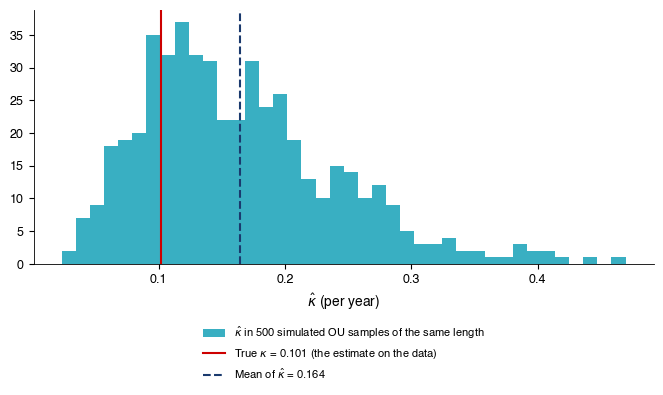

{'n': 18169,
 'a': np.float64(1.8323320445145317e-05),
 'b': np.float64(0.9995975062106368),
 'kappa': np.float64(0.10144885255591547),
 'se_kappa': 0.05144088306605011,
 'theta': np.float64(0.04552447995318332),
 'se_theta': 0.015535908651878474,
 'sigma': np.float64(0.013288258172257171),
 'half_life': np.float64(6.8324792552769775),
 'se_half_life': np.float64(3.4644922792812998),
 'stat_sd': np.float64(0.0295005076722635),
 'n_obs': 18170,
 'years': 72.1031746031746,
 'start': '1954-01-04',
 'k_mean': 0.16403549872671033,
 'k0_mean': 0.08173444897420007,
 'k0_q95': 0.21265169391656935,
 'p_rw': 0.2874251497005988,
 'kc_lo': -0.11400840291175865,
 'kc_hi': 0.19173281568199987,
 'resid_after_72': 0.06068319622422053,
 'k_sd': 0.0779952088249384,
 'bias': 0.06258664617079486,
 'k_corr': 0.03886220638512061,
 'hl_corr': 17.836022321813783,
 'share_above': 0.78,
 'approx_bias': 0.05547605943863512,
 'k_lo': np.float64(0.0006247217464572657),
 'k_hi': np.float64(0.2022729833653737)}

In [19]:
# Solution
def b4_vasicek(n_sim=500):
    """B4: Vasicek on the 3-month Treasury bill rate; the bias of the estimated kappa by simulation."""
    tb = read_fred('DTB3') / 100
    f = ou_mle(tb.values, DT)
    rng = np.random.default_rng(SEED + 20)
    k = ou_bias_mc(f['kappa'], f['theta'], f['sigma'], DT, len(tb), n_sim, rng)
    bias = k.mean() - f['kappa']
    kc = f['kappa'] - bias
    fig, ax = plt.subplots(figsize=(8, 3.3))
    ax.hist(k, bins=40, color=Teal, alpha=0.85, label=rf'$\hat\kappa$ in {n_sim} simulated OU samples of the same length')
    ax.axvline(f['kappa'], color=IDAred, lw=1.5, label=rf"True $\kappa$ = {f['kappa']:.3f} (the estimate on the data)")
    ax.axvline(k.mean(), color=MainBlue, lw=1.5, ls='--', label=rf'Mean of $\hat\kappa$ = {k.mean():.3f}')
    ax.set_xlabel(r'$\hat\kappa$ (per year)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch11_sem_kappa_bias')
    years = len(tb) * DT
    # inference after the correction: (i) a test of kappa = 0 (random walk, unit root) with the simulated null distribution
    # of kappa_hat (500 random walks of the same length, started at x_0, with the residual standard deviation);
    # (ii) approximate interval for the corrected kappa: kappa_c +/- 1.96 * simulated standard deviation of kappa_hat
    rw = np.random.default_rng(SEED + 24)
    sd = f['sigma'] * np.sqrt((1 - f['b'] ** 2) / (2 * f['kappa']))
    k0 = np.empty(n_sim)
    for i in range(n_sim):
        x = tb.values[0] + np.concatenate([[0.0], np.cumsum(sd * rw.standard_normal(len(tb) - 1))])
        k0[i] = -np.log(ou_mle(x, DT)['b']) / DT
    p_rw = (1 + np.sum(k0 >= f['kappa'])) / (1 + n_sim)
    return dict(f, n_obs=len(tb), years=years, start=str(tb.index[0].date()), k_mean=float(k.mean()),
                k0_mean=float(k0.mean()), k0_q95=float(np.quantile(k0, 0.95)), p_rw=float(p_rw),
                kc_lo=float(kc - 1.96 * k.std()), kc_hi=float(kc + 1.96 * k.std()),
                resid_after_72=float(np.exp(-kc * years)),
                k_sd=float(k.std()), bias=float(bias), k_corr=float(kc), hl_corr=float(np.log(2) / kc) if kc > 0 else None,
                share_above=float(np.mean(k > f['kappa'])), approx_bias=4 / years,
                k_lo=f['kappa'] - 1.96 * f['se_kappa'], k_hi=f['kappa'] + 1.96 * f['se_kappa'])


b4_vasicek()

### B4 Extended. Exact CIR, Euler and CKLS, 1954–2007 [Solved]

- Interpretation: which volatility specification do the data prefer, and does the answer change with the sampling frequency?

In [20]:
# Solution
def b4_likelihoods():
    """B4 Extended: exact CIR vs Euler and CKLS on DTB3, 1954-2007 (diffusion_fits of the lecture code)."""
    tb = read_fred('DTB3') / 100
    s = tb.loc['1954':'2007']
    return {'daily': short_rate_fits(s.values, DT), 'monthly': short_rate_fits(s.resample('ME').last().values, 1 / 12)}


L4 = b4_likelihoods()
pd.DataFrame({f: {m: v['kappa'] for m, v in L4[f].items() if isinstance(v, dict)} for f in L4}).round(4), L4['daily']['ckls']

(                daily  monthly
 vasicek_exact  0.1577   0.2005
 vasicek_euler  0.1577   0.1988
 cir_euler      0.0931   0.1435
 cir_exact      0.1125   0.1535
 ckls           0.0800   0.1440,
 {'kappa': np.float64(0.08001645619072931),
  'theta': np.float64(0.058416083890790865),
  'sigma': np.float64(0.12362068974487675),
  'gamma': np.float64(0.7699284746452901),
  'se_gamma': 0.007701702054107655,
  'se_gamma_rob': 0.019657441892159684,
  'se_gamma_hac': 0.03297572471664514,
  'hac_lags': 11,
  'se_kappa': 0.05661123400086741,
  'loglik': np.float64(78778.99161516027),
  'lr_g0': np.float64(7926.630732687103),
  'lr_g05': np.float64(1139.341326683556),
  'wald_g0': np.float64(1534.0755993251921),
  'wald_g05': np.float64(188.55732133693454),
  'wald_g0_hac': np.float64(545.1450405354637),
  'wald_g05_hac': np.float64(67.00523013904746),
  'hac_lags5': 55,
  'se_gamma_hac5': 0.05737658895256393,
  'wald_g0_hac5': np.float64(180.06583186417828),
  'wald_g05_hac5': np.float64(22.13237

### B5. Mean reversion of the VIX [Proposed]

- OU on ln VIX: half-life with CI, bias, ACF against the OU decay. Model: B4.
- Interpretation: what does the ACF pattern say about a one-factor OU model?

In [ ]:
# Your code here


### B6. Merton and a bootstrap likelihood-ratio test [Solved]

- MLE with Hessian standard errors; LR against GBM on the bounded space $\sigma \ge 5\%$; parametric bootstrap with 200 samples, same restriction and same six starting points.
- Interpretation: why is the $\chi^2_3$ distribution not valid here?

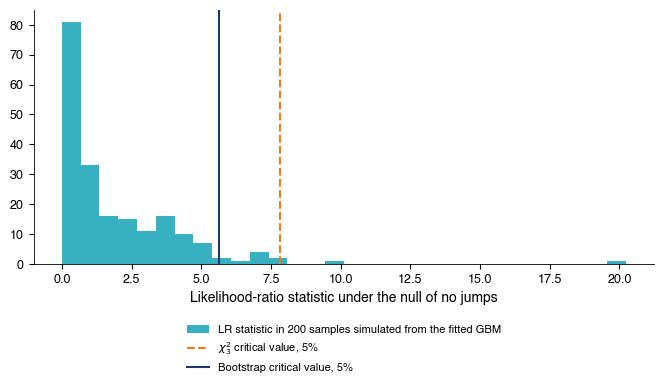

{'lr': np.float64(2400.6620623839917),
 'p_boot': 0.004975124378109453,
 'n_exceed': 0,
 'p_upper95': 0.014867039231272054,
 'sigma_min': 0.05,
 'crit95': 5.620875316635646,
 'chi2': 7.8147279032511765,
 'boot_mean': 1.8791751125903466,
 'boot_zero': 0.02,
 'moments': {'mean': np.float64(0.00033069593983456964),
  'var': np.float64(0.00012070520090642984),
  'skew': np.float64(-0.3093885819215241),
  'exkurt': np.float64(3.7072053661036772)},
 'n_boot': 200}

In [22]:
# Solution
def b6_merton_lr(n_boot=200, sigma_min=0.05, n_jobs=None):
    """B6: Merton on the S&P 500: parameters with standard errors; the LR test GBM vs Merton with a parametric bootstrap.
    The statistic is defined on the restricted space sigma >= 5% (the unrestricted likelihood is unbounded, B6 Extended),
    with the same six starting points for the observed sample and for every bootstrap sample."""
    r = rets['sp500'].values
    rng = np.random.default_rng(SEED + 22)
    n_jobs = os.cpu_count() if n_jobs is None else n_jobs
    res = lr_bootstrap(r, DT, n_boot, rng, sigma_min=sigma_min, n_jobs=n_jobs)
    mf = res['merton']
    fig, ax = plt.subplots(figsize=(8, 3.3))
    ax.hist(res['boot'], bins=30, color=Teal, alpha=0.85, label=f'LR statistic in {n_boot} samples simulated from the fitted GBM')
    ax.axvline(stats.chi2.ppf(0.95, 3), color=Orange, lw=1.5, ls='--', label=r'$\chi^2_3$ critical value, 5%')
    ax.axvline(res['crit95'], color=MainBlue, lw=1.5, label='Bootstrap critical value, 5%')
    ax.set_xlabel('Likelihood-ratio statistic under the null of no jumps')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch11_sem_lr_boot')
    mo = merton_moments(DT, mf['sigma'], mf['lam'], mf['mu_j'], mf['s_j'], mf['m'])
    return dict(lr=res['lr'], p_boot=res['p_boot'], n_exceed=res['n_exceed'], p_upper95=res['p_upper95'],
                sigma_min=sigma_min, crit95=res['crit95'], chi2=float(stats.chi2.ppf(0.95, 3)),
                boot_mean=float(res['boot'].mean()), boot_zero=float(np.mean(res['boot'] < 1e-6)),
                merton={k: v for k, v in mf.items()}, moments=mo, n_boot=n_boot)


res = b6_merton_lr()
{k: v for k, v in res.items() if k != 'merton'}

### B6 Extended. Profile likelihood in σ and the unbounded likelihood [Solved]

- Interpretation: is the likelihood bounded, and what does the reported MLE mean?

In [23]:
# Solution
def b6_profile(sigmas=(0.05, 0.02, 0.01)):
    """B6 Extended: Merton profile likelihood in sigma (other parameters re-estimated) and the MLE under sigma >= 5%."""
    r = rets['sp500'].values
    mf = merton_mle(r, DT)
    out = {'mle': dict(sigma=mf['sigma'], loglik=mf['loglik'])}
    x0 = np.array([mf['m'], np.log(mf['lam']), mf['mu_j'], np.log(mf['s_j'])])
    for sg in sigmas:
        nll = lambda q, sg=sg: -merton_logpdf(r, DT, q[0], sg, np.exp(q[1]), q[2], np.exp(q[3])).sum()
        best = None
        for lam0 in (np.exp(x0[1]), 2 * np.exp(x0[1]), 4 * np.exp(x0[1])):
            q0 = x0.copy()
            q0[1] = np.log(lam0)
            res = optimize.minimize(nll, q0, method='Nelder-Mead', options=dict(maxiter=20000, maxfev=20000, xatol=1e-8, fatol=1e-6))
            if best is None or res.fun < best.fun:
                best = res
        out[f'{sg:.2f}'] = dict(loglik=-best.fun, lam=float(np.exp(best.x[1])), s_j=float(np.exp(best.x[3])))
    # sup = +infinity: sigma -> 0 with m dt equal to an observed return; the contribution of that return
    i = int(np.argmin(np.abs(r - np.median(r))))
    w0 = np.exp(-mf['lam'] * DT)
    out['spike'] = {f'{sg:.0e}': float(np.log(w0) + stats.norm.logpdf(0, 0, sg * np.sqrt(DT))) for sg in (1e-2, 1e-4, 1e-8, 1e-16)}
    out['constrained_binding'] = bool(mf['sigma'] < 0.05)
    return out


b6_profile()

{'mle': {'sigma': np.float64(0.09442705779440107),
  'loglik': np.float64(29500.148269233257)},
 '0.05': {'loglik': np.float64(29422.456632720605),
  'lam': 302.4658401937637,
  's_j': 0.00928157187589338},
 '0.02': {'loglik': np.float64(29264.70461746258),
  'lam': 555.1212932999141,
  's_j': 0.0069866230367332735},
 '0.01': {'loglik': np.float64(29165.42517470373),
  'lam': 710.0752021951525,
  's_j': 0.006174309582618654},
 'spike': {'1e-02': 6.0466457107164855,
  '1e-04': 10.651815896704576,
  '1e-08': 19.862156268680756,
  '1e-16': 38.282837012633124},
 'constrained_binding': False}

### B7. Jumps in Bitcoin [Proposed]

- Merton MLE and the Lee–Mykland test. Model: B6.
- Interpretation: why do $\hat\lambda$ and the Lee–Mykland count differ so much?

In [ ]:
# Your code here


### B8. Heston parameters from the VIX [Proposed]

- CIR regression, CI for $\kappa$ and $\rho$, Feller ratio, two subperiods. Model: B4, B6.
- Interpretation: why is $\sqrt{\theta}$ from the VIX above the realised volatility?

In [ ]:
# Your code here


### B8 Extended. The affine correction of ξ and ρ from realised variance [Proposed]

- Interpretation: why is $\rho$ from realised variance much closer to zero?

In [ ]:
# Your code here


### B9. Nonparametric diffusion of the T-bill rate [Proposed]

- Nadaraya–Watson drift and diffusion, 1954–2007, with bandwidths $h/2$, $h$, $2h$. Model: B4 Extended.
- Interpretation: which parametric model lies inside the band, and can the drift be distinguished from zero?

In [ ]:
# Your code here


## Part C — open questions

### C1. Which continuous-time model fits BET and Bitcoin? [Proposed]

- Fit GBM, Merton and Heston (proxy $RV_t = \sum_{j=0}^{20} r_{t-j}^2/(21\Delta t)$); simulate 100 samples of each.
- Compare excess kurtosis, the Hill statistic of the largest losses and the ACF of $|r_t|$ with the data; the percentiles $q$ are descriptive (parameters not refitted).

In [ ]:
# Your code here


### C3. Is SPY volatility rough and persistent? Stage 1 [Proposed]

- SPY 5-minute bars, complete 09:30–16:00 New York sessions (78 bars); daily bipower variation $\mathrm{BV}_t$ and $x_t = \tfrac12\log\mathrm{BV}_t$.
- Estimate the roughness $\alpha$ by OLS on the log-variogram ($k = 1, \dots, 6$) and by NLLS averaged over $m = 10, \dots, 20$; fit the Cauchy ACF (memory parameter $\beta$) and an exponential (OU) ACF; compare with the lecture case study.
- Stages 2 (intraday bins) and 3 (forecasting) are described in the slides and are optional.

In [ ]:
# Your code here
